# TP2 : Classification automatique des emails/SMS
## Hany El Atlassi - CSCC


## Étape 0 : Importation des bibliothèques

In [2]:
import re

import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

In [3]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /home/theslender/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/theslender/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/theslender/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Étape 1 : Prétraitement des données
### Chargement du jeu de données

In [4]:
df = pd.read_csv("HANY EL ATLASSI - SMSSpamCollection.txt", sep="\t", names=["classe", "message"], header=0)
print(df.shape)
df.head()

(5572, 2)


,classe,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
df['classe'].value_counts()

classe
ham     4825
spam     747
Name: count, dtype: int64

### Nettoyage, tokenisation et suppression des mots vides

In [6]:
stop_words = set(stopwords.words('english'))
porter = PorterStemmer()

def clean_tokens(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
    return tokens

df['tokens'] = df['message'].apply(clean_tokens)
df[['message', 'tokens']].head()

,message,tokens
0,"Go until jurong point, crazy.. Available only ...","[go, jurong, point, crazy, available, bugis, g..."
1,Ok lar... Joking wif u oni...,"[ok, lar, joking, wif, oni]"
2,Free entry in 2 a wkly comp to win FA Cup fina...,"[free, entry, wkly, comp, win, fa, cup, final,..."
3,U dun say so early hor... U c already then say...,"[dun, say, early, hor, already, say]"
4,"Nah I don't think he goes to usf, he lives aro...","[nah, think, goes, usf, lives, around, though]"


### Deux configurations : avec stemming (Porter) et sans stemming

In [7]:
df['text_no_stem'] = df['tokens'].apply(lambda toks: ' '.join(toks))
df['text_stem'] = df['tokens'].apply(lambda toks: ' '.join(porter.stem(t) for t in toks))

df[['message', 'text_no_stem', 'text_stem']].head()

,message,text_no_stem,text_stem
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis great wo...,go jurong point crazi avail bugi great world l...
1,Ok lar... Joking wif u oni...,ok lar joking wif oni,ok lar joke wif oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...,free entri wkli comp win fa cup final tkt st m...
3,U dun say so early hor... U c already then say...,dun say early hor already say,dun say earli hor alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah think goes usf lives around though,nah think goe usf live around though


## Étape 4 : Séparation des données 

In [8]:
y = df['classe'].values
idx_train, idx_test = train_test_split(
    df.index, test_size=0.25, random_state=42, stratify=y
)
train_df = df.loc[idx_train]
test_df = df.loc[idx_test]
y_train = train_df['classe'].values
y_test = test_df['classe'].values

print(f"Train: {train_df.shape[0]} messages, Test: {test_df.shape[0]} messages")
print("Répartition train:", train_df['classe'].value_counts(normalize=True).to_dict())
print("Répartition test:", test_df['classe'].value_counts(normalize=True).to_dict())

Train: 4179 messages, Test: 1393 messages
Répartition train: {'ham': 0.8659966499162479, 'spam': 0.13400335008375208}
Répartition test: {'ham': 0.8657573582196698, 'spam': 0.1342426417803302}


## Étape 2 : Représentation des emails (TF-IDF)

Pour chaque configuration de prétraitement (avec/sans stemming), on construit deux représentations TF-IDF :
- **unigramme** : `TfidfVectorizer(ngram_range=(1, 1))`
- **bigramme** : `TfidfVectorizer(ngram_range=(2, 2))`


## Étape 3 : Classification

In [9]:
classifiers = [
    ("KNN (K=3)", KNeighborsClassifier, {"n_neighbors": 3}, "K=3"),
    ("KNN (K=5)", KNeighborsClassifier, {"n_neighbors": 5}, "K=5"),
    ("Decision Tree", DecisionTreeClassifier, {"random_state": 42}, "défaut"),
    ("SVM", SVC, {"random_state": 42}, "kernel=rbf (défaut)"),
]

In [10]:
results = []
fitted = {}

for stemming, text_col in [(True, 'text_stem'), (False, 'text_no_stem')]:
    for rep_name, ngram in [("TF-IDF unigram", (1, 1)), ("TF-IDF bigram", (2, 2))]:
        vectorizer = TfidfVectorizer(ngram_range=ngram)
        X_train = vectorizer.fit_transform(train_df[text_col])
        X_test = vectorizer.transform(test_df[text_col])

        for clf_name, clf_cls, params, param_str in classifiers:
            model = clf_cls(**params)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            acc = accuracy_score(y_test, y_pred)
            prec, rec, f1, _ = precision_recall_fscore_support(
                y_test, y_pred, average='weighted', zero_division=0
            )

            key = (rep_name, stemming, clf_name)
            fitted[key] = (model, vectorizer, y_pred)

            results.append({
                "Représentation": rep_name,
                "Stemming": "Oui" if stemming else "Non",
                "Classifieur": clf_name,
                "Paramètres": param_str,
                "Taille vocabulaire": X_train.shape[1],
                "Accuracy": round(acc, 4),
                "Precision": round(prec, 4),
                "Recall": round(rec, 4),
                "F1-score": round(f1, 4),
            })

results_df = pd.DataFrame(results)
results_df

,Représentation,Stemming,Classifieur,Paramètres,Taille vocabulaire,Accuracy,Precision,Recall,F1-score
0,TF-IDF unigram,Oui,KNN (K=3),K=3,5355,0.9282,0.9328,0.9282,0.9169
1,TF-IDF unigram,Oui,KNN (K=5),K=5,5355,0.9182,0.9252,0.9182,0.9021
2,TF-IDF unigram,Oui,Decision Tree,défaut,5355,0.9670,0.9664,0.9670,0.9666
3,TF-IDF unigram,Oui,SVM,kernel=rbf (défaut),5355,0.9799,0.9802,0.9799,0.9793
4,TF-IDF bigram,Oui,KNN (K=3),K=3,23122,0.9160,0.9234,0.9160,0.8988
5,TF-IDF bigram,Oui,KNN (K=5),K=5,23122,0.9009,0.9111,0.9009,0.8746
6,TF-IDF bigram,Oui,Decision Tree,défaut,23122,0.9569,0.9569,0.9569,0.9542
7,TF-IDF bigram,Oui,SVM,kernel=rbf (défaut),23122,0.9476,0.9506,0.9476,0.9420
8,TF-IDF unigram,Non,KNN (K=3),K=3,6446,0.9261,0.9319,0.9261,0.9135
9,TF-IDF unigram,Non,KNN (K=5),K=5,6446,0.9153,0.9228,0.9153,0.8977


### Tableau récapitulatif des expériences (trié par F1-score décroissant)

In [11]:
results_sorted = results_df.sort_values("F1-score", ascending=False).reset_index(drop=True)
results_sorted

,Représentation,Stemming,Classifieur,Paramètres,Taille vocabulaire,Accuracy,Precision,Recall,F1-score
0,TF-IDF unigram,Oui,SVM,kernel=rbf (défaut),5355,0.9799,0.9802,0.9799,0.9793
1,TF-IDF unigram,Non,SVM,kernel=rbf (défaut),6446,0.9777,0.9781,0.9777,0.9769
2,TF-IDF unigram,Oui,Decision Tree,défaut,5355,0.9670,0.9664,0.9670,0.9666
3,TF-IDF unigram,Non,Decision Tree,défaut,6446,0.9576,0.9572,0.9576,0.9574
4,TF-IDF bigram,Non,Decision Tree,défaut,23650,0.9591,0.9593,0.9591,0.9565
5,TF-IDF bigram,Oui,Decision Tree,défaut,23122,0.9569,0.9569,0.9569,0.9542
6,TF-IDF bigram,Oui,SVM,kernel=rbf (défaut),23122,0.9476,0.9506,0.9476,0.9420
7,TF-IDF bigram,Non,SVM,kernel=rbf (défaut),23650,0.9462,0.9493,0.9462,0.9402
8,TF-IDF unigram,Oui,KNN (K=3),K=3,5355,0.9282,0.9328,0.9282,0.9169
9,TF-IDF unigram,Non,KNN (K=3),K=3,6446,0.9261,0.9319,0.9261,0.9135


## Analyse et interprétation

### Comparaison visuelle des 16 combinaisons (F1-score)

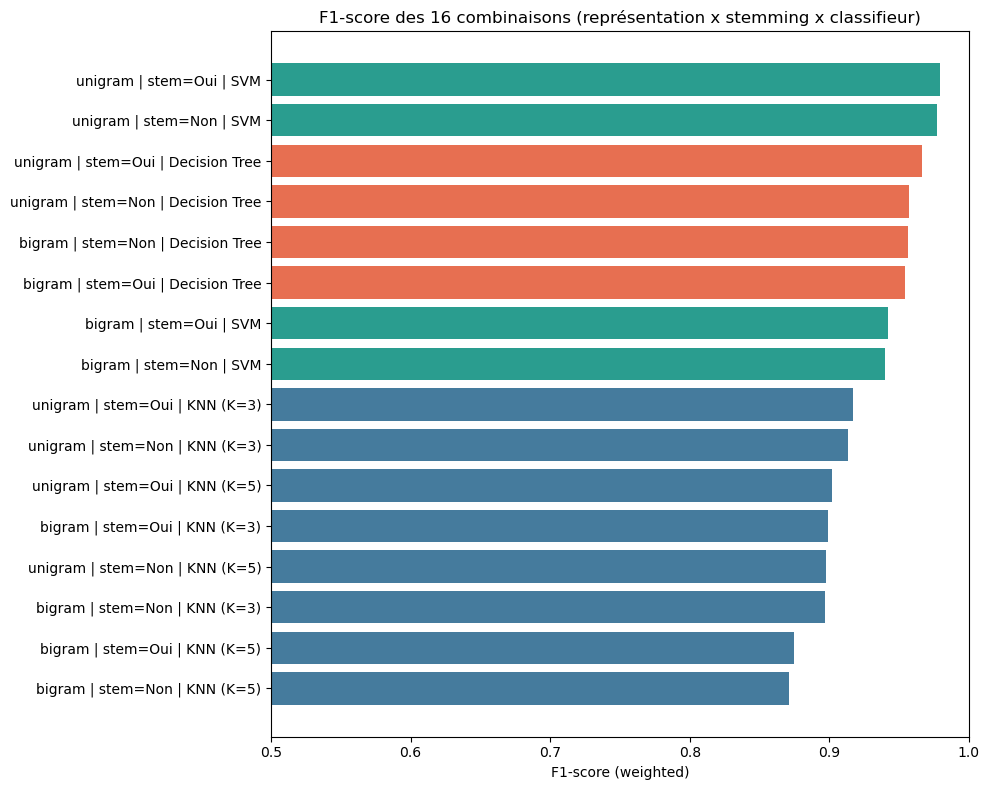

In [12]:
labels = (
    results_sorted["Représentation"].str.replace("TF-IDF ", "")
    + " | stem=" + results_sorted["Stemming"]
    + " | " + results_sorted["Classifieur"]
)

plt.figure(figsize=(10, 8))
colors = ["#2a9d8f" if c == "SVM" else "#e76f51" if c == "Decision Tree" else "#457b9d"
          for c in results_sorted["Classifieur"]]
plt.barh(labels, results_sorted["F1-score"], color=colors)
plt.gca().invert_yaxis()
plt.xlabel("F1-score (weighted)")
plt.title("F1-score des 16 combinaisons (représentation x stemming x classifieur)")
plt.xlim(0.5, 1.0)
plt.tight_layout()
plt.show()

### Impact du stemming de Porter

In [13]:
results_df.groupby("Stemming")[["Accuracy", "Precision", "Recall", "F1-score"]].mean().round(4)

,Accuracy,Precision,Recall,F1-score
Stemming,,,,
Non,0.9369,0.9413,0.9369,0.9262
Oui,0.9393,0.9433,0.9393,0.9293


### Unigrammes vs bigrammes

In [14]:
results_df.groupby("Représentation")[["Accuracy", "Precision", "Recall", "F1-score", "Taille vocabulaire"]].mean().round(4)

,Accuracy,Precision,Recall,F1-score,Taille vocabulaire
Représentation,,,,,
TF-IDF bigram,0.9300,0.9353,0.9300,0.9167,23386.0
TF-IDF unigram,0.9462,0.9493,0.9462,0.9388,5900.5


### Comparaison des classifieurs 

In [15]:
results_df.groupby("Classifieur")[["Accuracy", "Precision", "Recall", "F1-score"]].mean().round(4).sort_values("F1-score", ascending=False)

,Accuracy,Precision,Recall,F1-score
Classifieur,,,,
SVM,0.9628,0.9646,0.9628,0.9596
Decision Tree,0.9602,0.9600,0.9602,0.9587
KNN (K=3),0.9212,0.9276,0.9212,0.9064
KNN (K=5),0.9083,0.9171,0.9083,0.8863


### Matrice de confusion

In [18]:
best_row = results_sorted.iloc[0]
print("Meilleure combinaison :")
print(best_row)

key = (best_row["Représentation"], best_row["Stemming"] == "Oui", best_row["Classifieur"])
best_model, best_vectorizer, best_pred = fitted[key]

print('\n' + classification_report(y_test, best_pred))

Meilleure combinaison :
Représentation             TF-IDF unigram
Stemming                              Oui
Classifieur                           SVM
Paramètres            kernel=rbf (défaut)
Taille vocabulaire                   5355
Accuracy                           0.9799
Precision                          0.9802
Recall                             0.9799
F1-score                           0.9793
Name: 0, dtype: object

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99      1206
        spam       0.99      0.86      0.92       187

    accuracy                           0.98      1393
   macro avg       0.99      0.93      0.95      1393
weighted avg       0.98      0.98      0.98      1393



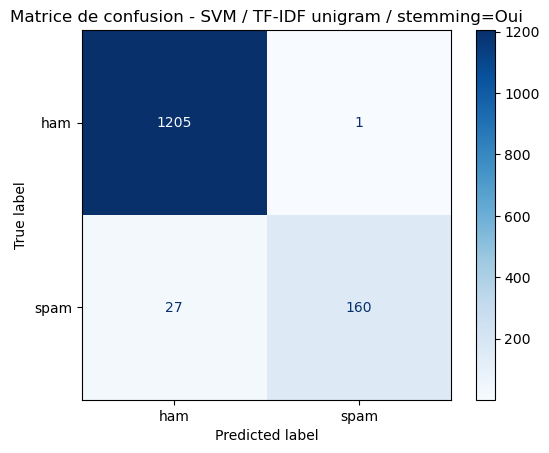

In [17]:
cm = confusion_matrix(y_test, best_pred, labels=["ham", "spam"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["ham", "spam"])
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Matrice de confusion - {best_row['Classifieur']} / {best_row['Représentation']} / stemming={best_row['Stemming']}")
plt.show()

La matrice de confusion montre que la quasi-totalité des erreurs du meilleur modèle sont des faux négatifs (des spams classés à tort comme `ham`), et non des faux positifs (aucun ou presque aucun `ham` légitime classé comme spam). C'est le comportement le plus souhaitable pour un filtre anti-spam.

## Conclusion

**1. Quelle représentation textuelle donne les meilleurs résultats : unigrammes ou bigrammes ?**

Les unigrammes ont de meilleurs résultats (F1-score moyen = 0.94 contre = 0.92, et le meilleur modèle global est en unigramme). Beaucoup de bigrammes n'apparaissent qu'une seule fois dans tout le corpus.

**2. Le stemming améliore-t-il les performances de classification ?**

Le stemming de Porter n'apporte presque pas de gain. Il aide surtout en réduisant la taille du vocabulaire  en regroupant des variantes morphologiques comme *free/freely*, *win/winner/winning*, ce qui limite la dispersion des poids TF-IDF, mais l'effet reste secondaire par rapport au choix du classifieur ou de la représentation.

**3. Quel choix de K est le plus performant pour KNN : 3 ou 5 ?**

K=3 obtient de meilleurs résultats que K=5 (F1-score moyen = 0.906 contre = 0.886). Avec un K plus petit, le classifieur est moins sensible à la dilution causée par la classe majoritaire (`ham`) lors du vote de voisinage.

**4. Quel algorithme obtient les meilleurs résultats : KNN, Decision Tree ou SVM ?**

Le SVM obtient les meilleurs résultats en moyenne (F1-score moyen = 0.960), suivi de très près par le Decision Tree (= 0.959). Les deux KNN sont en retrait (= 0.906 pour K=3, = 0.886 pour K=5). Le SVM tire parti de sa capacité à bien séparer des données en haute dimension et creuses, typiques de la représentation TF-IDF.

**5. Quelle est la meilleure combinaison globale ?**

La meilleure combinaison est : TF-IDF unigramme + stemming de Porter + SVM, avec une Accuracy = 0.980, une Precision = 0.980, un Recall = 0.980 et un F1-score = 0.979 (moyenne pondérée). Sur la classe `spam` seule, ce modèle atteint une precision = 0.99 et un recall = 0.86 : il ne se trompe presque jamais quand il prédit "spam", mais rate encore une partie des spams (faux négatifs), ce qui reste préférable à des faux positifs dans un contexte de filtrage d'emails/SMS.

**6. Quelles sont les principales difficultés ou limites rencontrées lors de la classification des emails ?**

- **Déséquilibre des classes** (= 87% `ham` / 13% `spam`) : l'accuracy globale est optimiste et peut masquer un mauvais recall sur la classe minoritaire (`spam`), qui est pourtant la classe d'intérêt.
- **Messages très courts** : les SMS contiennent peu de mots, ce qui rend les représentations bigrammes très creuses et peu généralisables.
- **Vocabulaire bruité** : fautes de frappe, abréviations SMS, chiffres/symboles (numéros, montants), qui ne sont pas toujours bien capturés après suppression des chiffres/ponctuation.
- **Sensibilité de KNN à la dimensionnalité** : dans un espace TF-IDF de plusieurs milliers de dimensions, la notion de distance devient moins discriminante ("fléau de la dimension"), ce qui explique les performances plus faibles de KNN par rapport à SVM et Decision Tree.
- **Risque de sur-apprentissage du Decision Tree**, dont les performances sont très proches de celles du SVM sur ce split mais qui est réputé plus instable/moins robuste en généralisation sur de nouvelles données.